# Digit Recognition
Pipeline: **HOG features → SGD classifier**

In [49]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [50]:
DATA_DIR = 'data'
IMG_SIZE = (28, 28)

_HOG = cv2.HOGDescriptor(
    _winSize=IMG_SIZE, _blockSize=(8, 8),
    _blockStride=(4, 4), _cellSize=(4, 4), _nbins=9
)

def find_train_image(img_id, category):
    path = os.path.join(DATA_DIR, 'train', 'train', str(category), f'{img_id}.png')
    if os.path.exists(path):
        return path
    for cat in range(10):
        p = os.path.join(DATA_DIR, 'train', 'train', str(cat), f'{img_id}.png')
        if os.path.exists(p):
            return p
    return None

def find_test_image(img_id):
    for candidate in [
        os.path.join(DATA_DIR, 'test', f'{img_id}.png'),
        *[os.path.join(DATA_DIR, 'test', 'test', str(c), f'{img_id}.png') for c in range(10)],
        os.path.join(DATA_DIR, 'test', 'test', f'{img_id}.png'),
    ]:
        if os.path.exists(candidate):
            return candidate
    return None

def preprocess(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f'cv2.imread failed to load image: {path}')
    img = cv2.resize(img, IMG_SIZE)
    return _HOG.compute(img).flatten()

## Sample Images

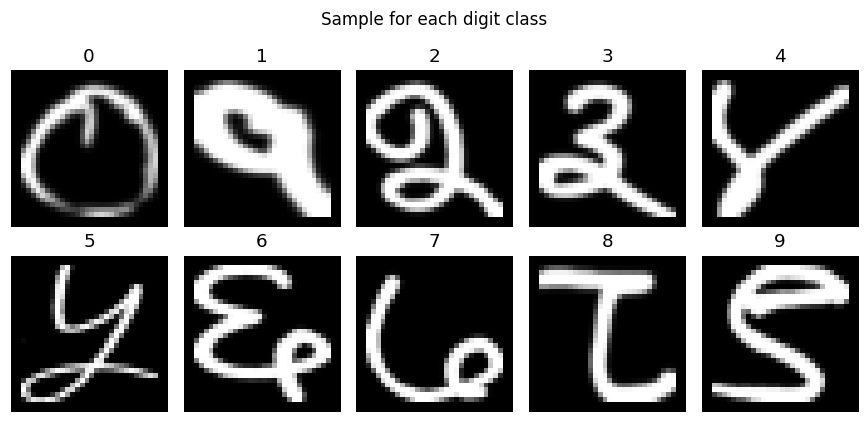

In [51]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))

fig, axes = plt.subplots(2, 5, figsize=(8, 4))
fig.suptitle('Sample for each digit class', fontsize=11)

for digit, ax in enumerate(axes.flat):
    row = train_df[train_df['Category'] == digit].iloc[0]
    path = find_train_image(row['Id'], row['Category'])
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(str(digit), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Load Training Data

17000 samples 288 HOG features each 0 missing


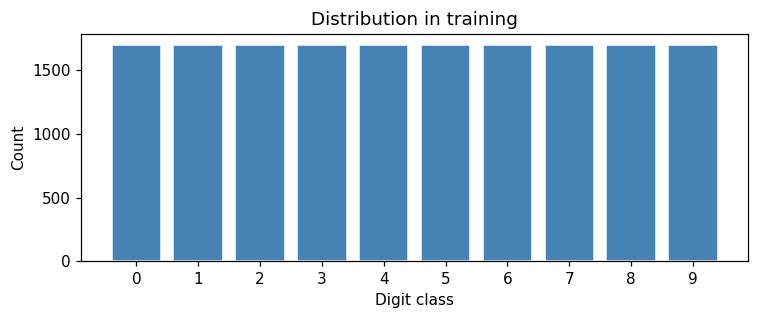

In [52]:
X_train, y_train = [], []
missing = 0

for _, row in train_df.iterrows():
    path = find_train_image(row['Id'], row['Category'])
    if path is None:
        missing += 1
        continue
    X_train.append(preprocess(path))
    y_train.append(int(row['Category']))

X_train = np.array(X_train)
y_train = np.array(y_train)
print(f'{len(X_train)} samples {X_train.shape[1]} HOG features each {missing} missing')

fig, ax = plt.subplots(figsize=(7, 3))
unique, counts = np.unique(y_train, return_counts=True)
ax.bar(unique, counts, color='steelblue', edgecolor='white')
ax.set_xlabel('Digit class'); ax.set_ylabel('Count')
ax.set_title('Distribution in training')
ax.set_xticks(unique)
plt.tight_layout(); plt.show()

## Train Classifier

In [ ]:
from sklearn.model_selection import train_test_split

MODEL_PATH = 'model.joblib'

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

if os.path.exists(MODEL_PATH):
    print('Loading saved model — skipping training')
    clf = joblib.load(MODEL_PATH)
    train_acc = np.mean(clf.predict(X_tr) == y_tr)
    val_acc   = np.mean(clf.predict(X_val) == y_val)
    print(f'Loaded  train: {train_acc:.2%}  val: {val_acc:.2%}')
else:
    candidates = {
        'SGD (linear)':  Pipeline([('scaler', StandardScaler()), ('clf', SGDClassifier(loss='hinge', max_iter=50000, random_state=42, n_jobs=-1))]),
        'SVC (RBF)':     Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=10, gamma='scale', random_state=42))]),
        'Random Forest': Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))]),
    }

    results = {}
    for name, pipeline in candidates.items():
        pipeline.fit(X_tr, y_tr)
        tr_acc = np.mean(pipeline.predict(X_tr) == y_tr)
        v_acc  = np.mean(pipeline.predict(X_val) == y_val)
        results[name] = {'model': pipeline, 'train_acc': tr_acc, 'val_acc': v_acc}
        print(f'{name:20s}  train: {tr_acc:.2%}  val: {v_acc:.2%}')

    best_name = max(results, key=lambda k: results[k]['val_acc'])
    clf       = results[best_name]['model']
    train_acc = results[best_name]['train_acc']
    val_acc   = results[best_name]['val_acc']
    print(f'\nBest: {best_name}  (val {val_acc:.2%})')
    joblib.dump(clf, MODEL_PATH)
    print(f'Saved to {MODEL_PATH}')

## Evaluation — Confusion Matrix

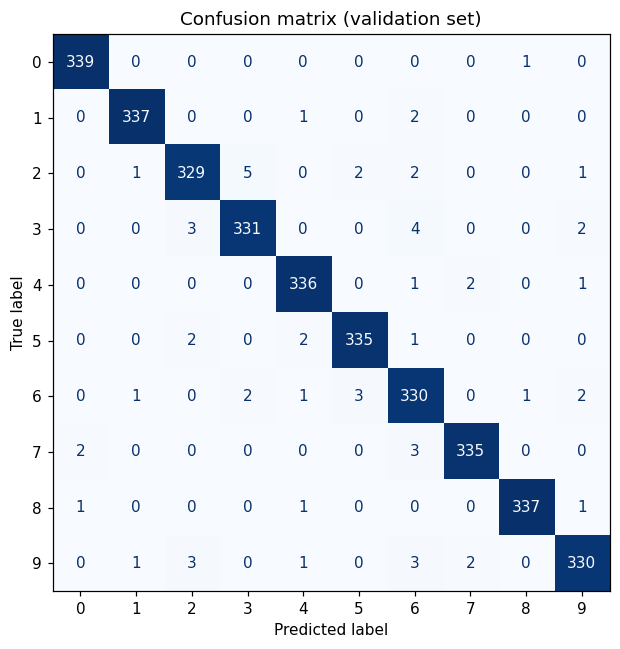

In [54]:
cm = confusion_matrix(y_val, clf.predict(X_val))
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix (validation set)')
plt.tight_layout(); plt.show()

## Predict Test Set

Saved 3000 to submission.csv
Validation acc: 98.21%  


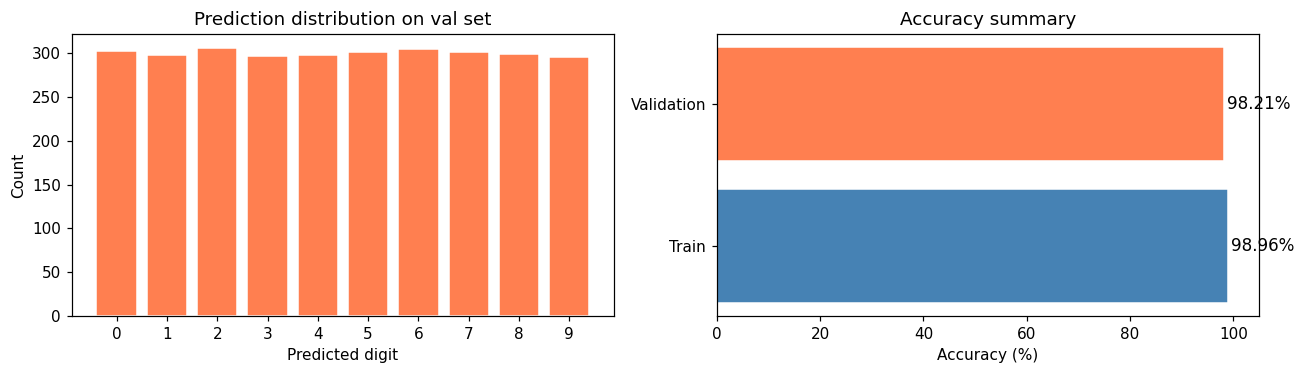

In [ ]:
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
predictions = []

for img_id in test_df['Id']:
    path = find_test_image(img_id)
    if path is None:
        print(f'WARNING: test image {img_id} not found — skipping (will not appear in submission)')
        continue
    else:
        feat = preprocess(path).reshape(1, -1)
        predictions.append(clf.predict(feat)[0])

submission = pd.DataFrame({'Id': test_df['Id'], 'Category': predictions})
submission.to_csv('submission.csv', index=False)
print(f'Saved {len(submission)} to submission.csv')
print(f'Validation acc: {val_acc:.2%}  ')

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

unique, counts = np.unique(predictions, return_counts=True)
axes[0].bar(unique, counts, color='coral', edgecolor='white')
axes[0].set_xlabel('Predicted digit'); axes[0].set_ylabel('Count')
axes[0].set_title('Prediction distribution on test set')
axes[0].set_xticks(unique)

axes[1].barh(['Train', 'Validation'], [train_acc * 100, val_acc * 100],
             color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_xlim(0, 105)
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_title('Accuracy summary')
for i, v in enumerate([train_acc, val_acc]):
    axes[1].text(v * 100 + 0.5, i, f'{v:.2%}', va='center', fontsize=11)

plt.tight_layout(); plt.show()